<h1 align='center' style='color:purple'>Clustering With K Means - Python Tutorial</h1>

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [3]:
df.describe()

,Age,Income($)
count,22.000000,22.000000
mean,34.818182,90431.818182
std,5.901060,43505.964412
min,26.000000,45000.000000
25%,29.000000,58500.000000
50%,36.500000,67500.000000
75%,39.750000,135250.000000
max,43.000000,162000.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       22 non-null     object
 1   Age        22 non-null     int64 
 2   Income($)  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 656.0+ bytes


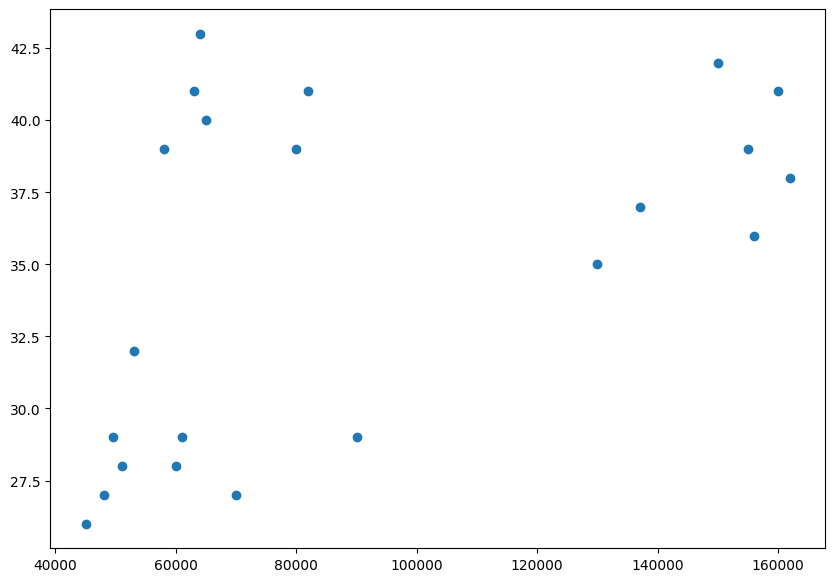

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.scatter(df["Income($)"],df["Age"])
plt.show()

In [6]:
from sklearn.cluster import KMeans

km=KMeans(n_clusters=3)
km

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [7]:
y_predicted=km.fit_predict(df[["Age","Income($)"]])

In [8]:
y_predicted

array([0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [9]:
df["cluster"]=y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


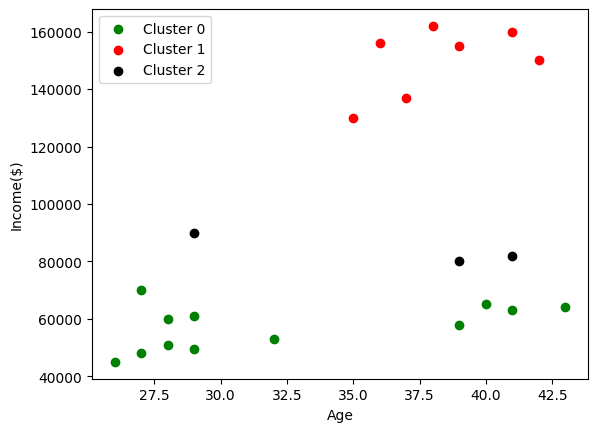

In [10]:
df0=df[df["cluster"]==0]
df1=df[df["cluster"]==1]
df2=df[df["cluster"]==2]

plt.scatter(df0["Age"],df0["Income($)"],color="green",label="Cluster 0")
plt.scatter(df1["Age"],df1["Income($)"],color="red",label="Cluster 1")
plt.scatter(df2["Age"],df2["Income($)"],color="black",label="Cluster 2")

plt.xlabel("Age")
plt.ylabel("Income($)")
plt.legend()
plt.show()

# this happened because scaling problems


In [12]:
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
df[["Age","Income($)"]]=scaler.fit_transform(df[["Age","Income($)"]])
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


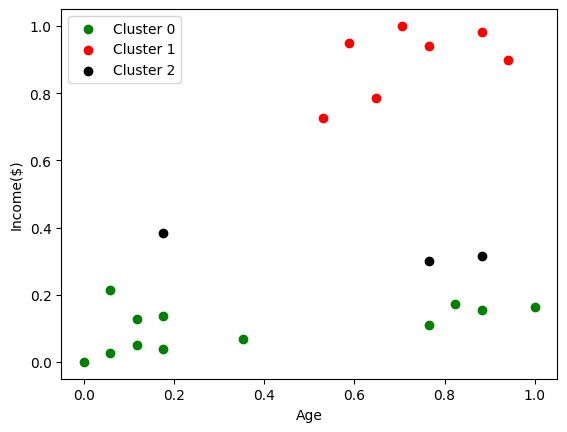

In [14]:
df0=df[df["cluster"]==0]
df1=df[df["cluster"]==1]
df2=df[df["cluster"]==2]

plt.scatter(df0["Age"],df0["Income($)"],color="green",label="Cluster 0")
plt.scatter(df1["Age"],df1["Income($)"],color="red",label="Cluster 1")
plt.scatter(df2["Age"],df2["Income($)"],color="black",label="Cluster 2")

plt.xlabel("Age")
plt.ylabel("Income($)")
plt.legend()
plt.show()

# its still the same,But we have to do from first we  have to train it with that normalized values 


In [15]:
km=KMeans(n_clusters=3)
y_predicted=km.fit_predict(df[["Age","Income($)"]])
y_predicted

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [16]:
df["cluster"]=y_predicted

In [17]:
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


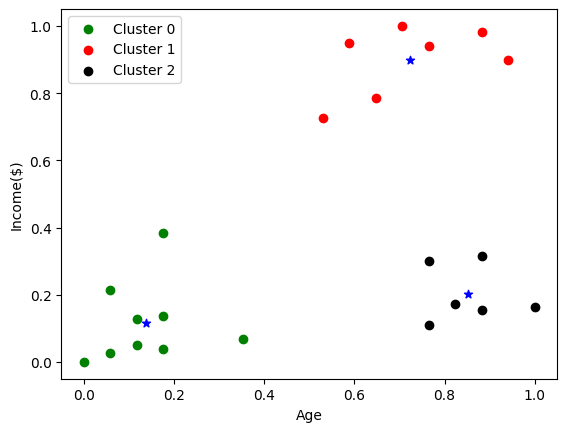

In [21]:
df0=df[df["cluster"]==0]
df1=df[df["cluster"]==1]
df2=df[df["cluster"]==2]

plt.scatter(df0["Age"],df0["Income($)"],color="green",label="Cluster 0")
plt.scatter(df1["Age"],df1["Income($)"],color="red",label="Cluster 1")
plt.scatter(df2["Age"],df2["Income($)"],color="black",label="Cluster 2")
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='blue',marker="*")

plt.xlabel("Age")
plt.ylabel("Income($)")
plt.legend()
plt.show()

# so now it works

In [19]:
dir(km)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_algorithm',
 '_build_request_for_signature',
 '_check_mkl_vcomp',
 '_check_params_vs_input',
 '_check_test_data',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_init_centroids',
 '_n_features_out',
 '_n_init',
 '_n_threads',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_

In [20]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

In [22]:
k_rng=range(1,10)
sse=[]

for k in k_rng:
    km=KMeans(n_clusters=k)
    km.fit(df[["Age","Income($)"]])
    sse.append(km.inertia_)

In [23]:
sse

[5.434011511988179,
 2.3456144914725936,
 0.4750783498553096,
 0.3625079900797329,
 0.30758486079756764,
 0.25821107816216954,
 0.2025441766905849,
 0.15680194058776267,
 0.10824862283029266]

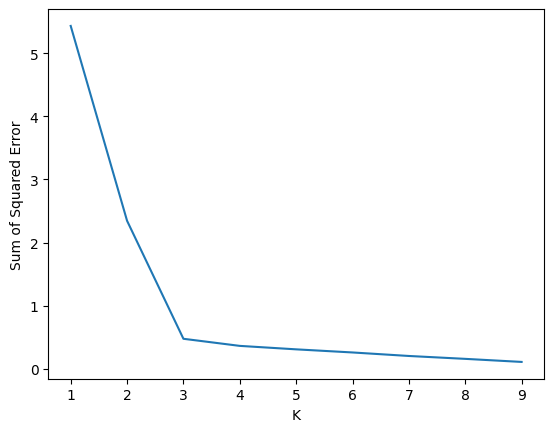

In [24]:
plt.xlabel("K")
plt.ylabel("Sum of Squared Error")
plt.plot(k_rng,sse)